# Example-08: Twiss from test signals

In [1]:
# Import

import numpy
import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [3]:
# This example is similar to the previous one, but test TbT data is generated using Model functions
# Quadrupole errors are added to each sector

In [4]:
# Set model

model = Model(path='../config.yaml', dtype=dtype, device=device)

# Set errors

model.make_error(5.0E-4, 5.0E-4, length=0.0)

# Set transport

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

# Set initial condition

initial = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**12

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)

True


In [5]:
# Set correct twiss data at monitor locations

from harmonica.parameterization import wolski_to_cs

ax_m, bx_m, ay_m, by_m = torch.stack([wolski_to_cs(model.out_wolski[i]) for i in model.monitor_index]).T

ax_m, bx_m, ay_m, by_m = ax_m.cpu().numpy(), bx_m.cpu().numpy(), ay_m.cpu().numpy(), by_m.cpu().numpy()

probe = torch.tensor(model.monitor_index)
other = probe.roll(-1, 0)

fx_m, fy_m = model.out_advance.T

fx_m = fx_m.roll(1, 0).cumsum(-1)
fx_m = fx_m[other] - fx_m[probe]
fx_m[-1] += 2.0*numpy.pi*model.out_tune[0]

fy_m = fy_m.roll(1, 0).cumsum(-1)
fy_m = fy_m[other] - fy_m[probe]
fy_m[-1] += 2.0*numpy.pi*model.out_tune[1]

fx_m, fy_m = fx_m.cpu().numpy(), fy_m.cpu().numpy()


print(torch.stack([model.nux, model.nuy]))
print(model.out_tune)

tensor([8.536883098737e+00, 7.576774633326e+00], dtype=torch.float64)
tensor([8.539286888932e+00, 7.571677319422e+00], dtype=torch.float64)


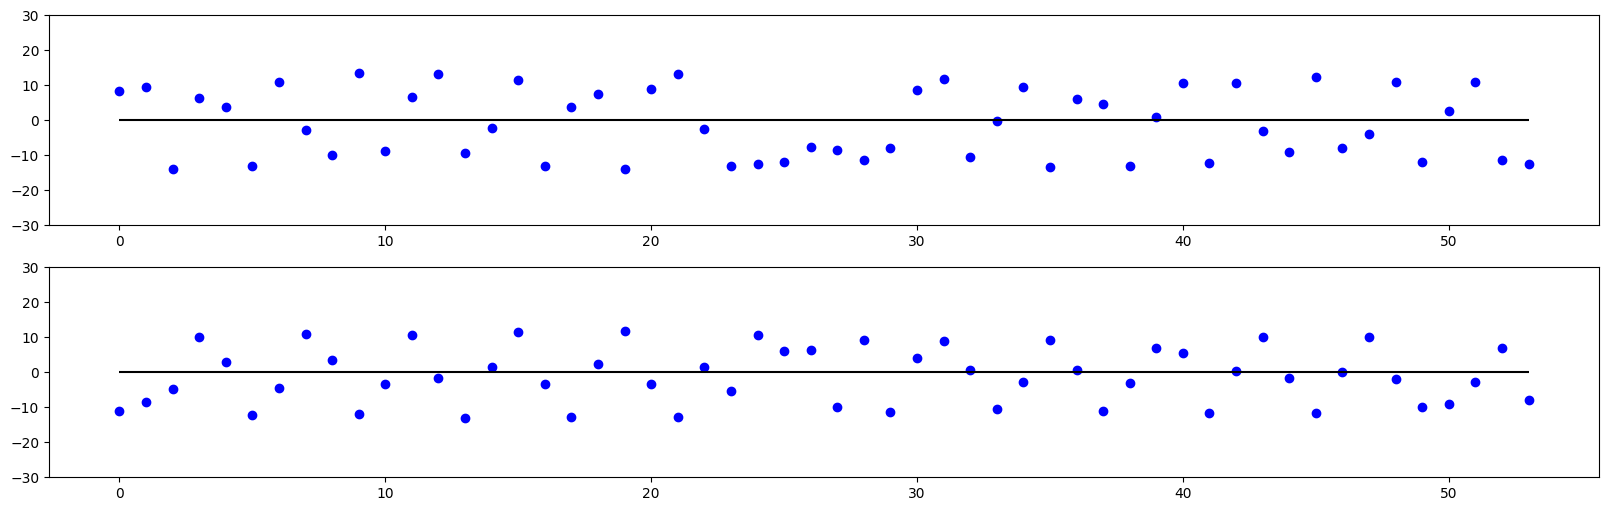

In [6]:
# Compare model twiss with correct twiss

plt.figure(figsize=(20, 3*2))

ax1 = plt.subplot(211)
ax1.scatter(range(model.monitor_count), 100*(bx_m - model.bx[model.monitor_index].cpu().numpy())/model.bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax1.hlines(0, 0, model.monitor_count - 1, colors='black')
ax1.set_ylim(-30, +30)

ax2 = plt.subplot(212)
ax2.scatter(range(model.monitor_count), 100*(by_m - model.by[model.monitor_index].cpu().numpy())/model.by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax2.hlines(0, 0, model.monitor_count - 1, colors='black')
ax2.set_ylim(-30, +30)

plt.show()

In [7]:
# Compute reference parameters (frequency, amplitude and phase)

length = 4096
w = Window(length, 'cosine_window', 4.0, dtype=dtype, device=device)

x = Data.from_data(w, trajectory[model.monitor_index, :, 0])
y = Data.from_data(w, trajectory[model.monitor_index, :, 2])

f = Frequency(x)
x.window_remove_mean()
x.window_apply()
f('parabola')
x.reset()
ref_nux, ref_sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
d = Decomposition(x)
result, _ = d.harmonic_sum(ref_nux, w.window, x.data)
_, _, ref_ax, ref_fx = result.T

f = Frequency(y)
y.window_remove_mean()
y.window_apply()
f('parabola')
y.reset()
ref_nuy, ref_sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
d = Decomposition(y)
result, _ = d.harmonic_sum(ref_nuy, w.window, y.data)
_, _, ref_ay, ref_fy = result.T

In [8]:
# Set noise

noise_x = 1.0E-6*(25.0 + 25.0*torch.rand(x.size, dtype=dtype, device=device))
noise_y = 1.0E-6*(25.0 + 25.0*torch.rand(y.size, dtype=dtype, device=device))

nux= 0.539286928, sigma_nux=5.9630139e-07, error_nux=3.92377855e-08

(ax - ref_ax).abs().sum().item()=0.000108154809

(fx - ref_fx).abs().sum().item()=0.0315915064



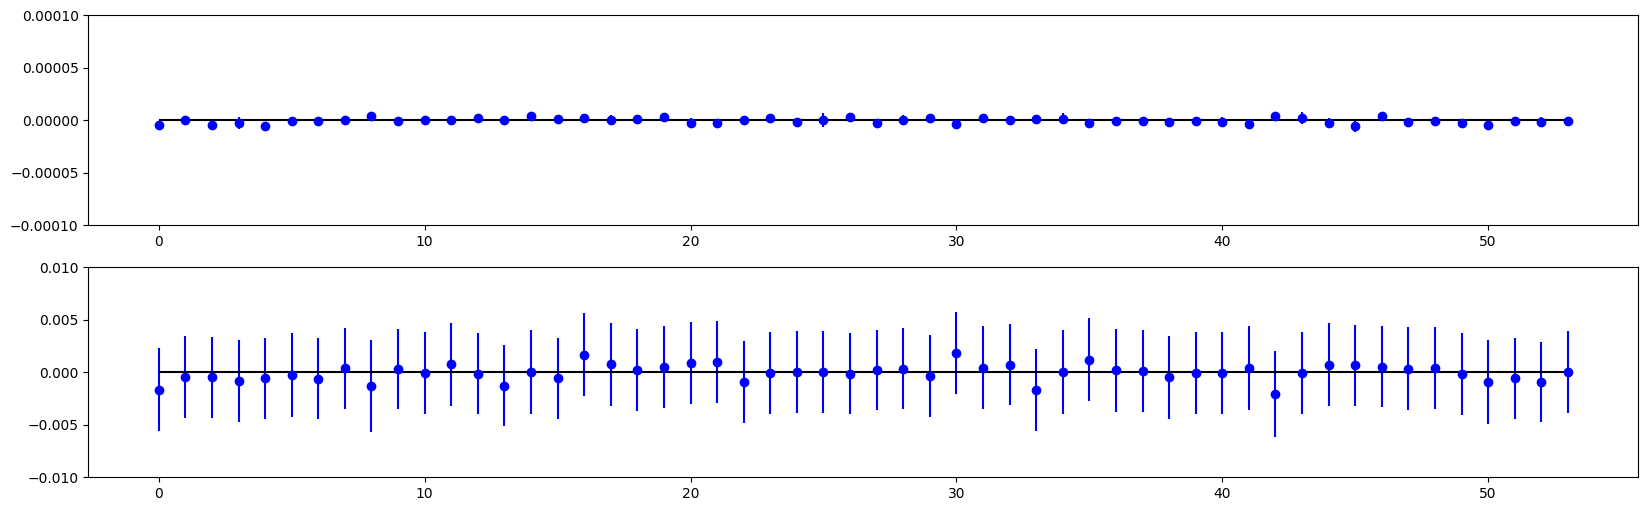

In [9]:
# Compute frequency, amplitude and phase for x plane

length = 1024
w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
d = Data.from_data(w, x.data[:, :length])
d.add_noise(noise_x)
d.data.copy_(d.work)

# Frequency

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
nux, sigma_nux = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(ref_nux - nux).item():12.9}')
print()

# Amplitude & phase

d = Decomposition(d)

ax, sigma_ax, _ = d.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
print(f'{(ax - ref_ax).abs().sum().item()=:12.9}')
print()

fx, sigma_fx, _ = d.harmonic_phase(nux, length=512, order=0.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')
print(f'{(fx - ref_fx).abs().sum().item()=:12.9}')
print()

plt.figure(figsize=(20, 3*2))
ax1 = plt.subplot(211)
ax1.errorbar(range(x.size), (ax - ref_ax).cpu().numpy(), yerr=sigma_ax.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax1.hlines(0, 0, x.size - 1, colors='black')
ax1.set_ylim(-1.0E-4, +1.0E-4)
ax2 = plt.subplot(212)
ax2.errorbar(range(x.size), (fx - ref_fx).cpu().numpy(), yerr=sigma_fx.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax2.hlines(0, 0, x.size - 1, colors='black')
ax2.set_ylim(-1.0E-2, +1.0E-2)
plt.show()

# Coupling
axy, sigma_axy, _ = d.harmonic_amplitude(ref_nuy, length=256, order=1.0, error=True, sigma_frequency=None, shift=True, count=64, step=8, method='noise')

nuy= 0.571677059, sigma_nuy=8.30109851e-07, error_nuy=2.60914373e-07

(ay - ref_ay).abs().sum().item()=9.74505226e-05

(fy - ref_fy).abs().sum().item()=0.0617839667



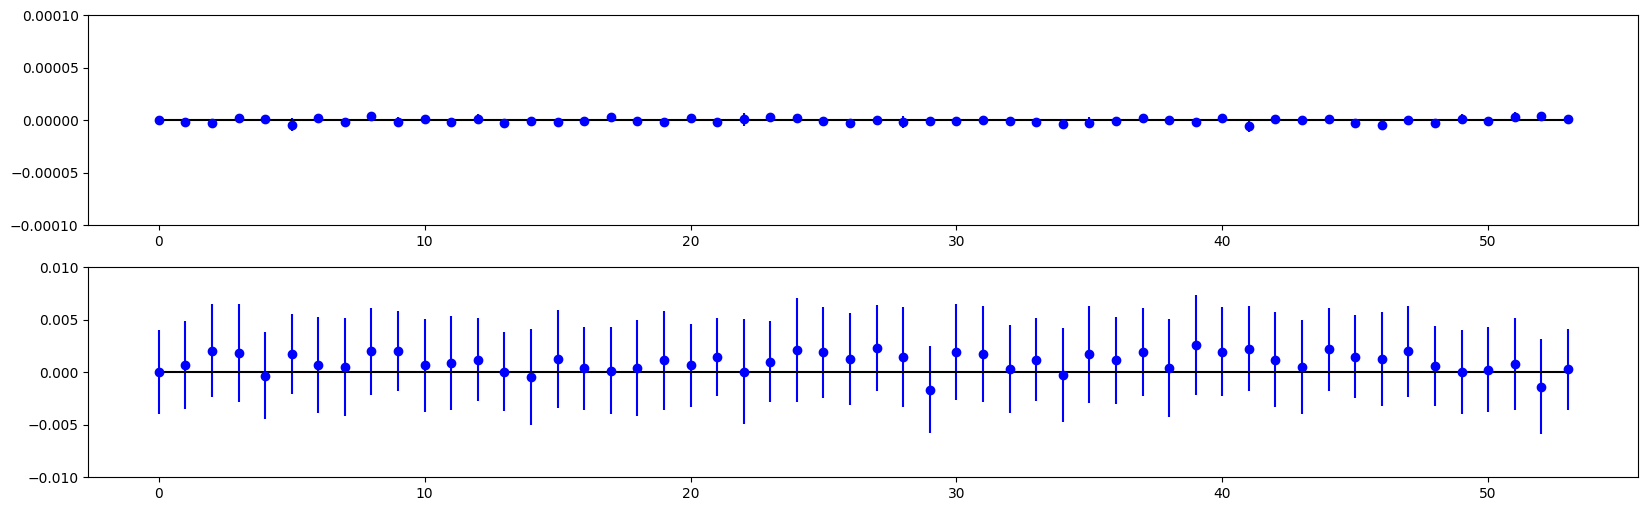

In [10]:
# Compute frequency, amplitude and phase for y plane

length = 1024
w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)
d = Data.from_data(w, y.data[:, :length])
d.add_noise(noise_y)
d.data.copy_(d.work)

# Frequency

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
nuy, sigma_nuy = 1.0 - f.frequency.mean(), f.frequency.std()
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(ref_nuy - nuy).item():12.9}')
print()

# Amplitude & phase

d = Decomposition(d)

ay, sigma_ay, _ = d.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
print(f'{(ay - ref_ay).abs().sum().item()=:12.9}')
print()

fy, sigma_fy, _ = d.harmonic_phase(nuy, length=512, order=0.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')
print(f'{(fy - ref_fy).abs().sum().item()=:12.9}')
print()

plt.figure(figsize=(20, 3*2))
ax1 = plt.subplot(211)
ax1.errorbar(range(y.size), (ay - ref_ay).cpu().numpy(), yerr=sigma_ay.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax1.hlines(0, 0, y.size - 1, colors='black')
ax1.set_ylim(-1.0E-4, +1.0E-4)
ax2 = plt.subplot(212)
ax2.errorbar(range(y.size), (fy - ref_fy).cpu().numpy(), yerr=sigma_fy.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax2.hlines(0, 0, y.size - 1, colors='black')
ax2.set_ylim(-1.0E-2, +1.0E-2)
plt.show()

# Coupling
ayx, sigma_ayx, _ = d.harmonic_amplitude(ref_nux, length=256, order=1.0, error=True, sigma_frequency=None, shift=True, count=64, step=8, method='noise')

In [11]:
# Set table

table = Table([name for name, kind in zip(model.name, model.kind) if kind == 'MONITOR'], nux, nuy, ax, ay, fx, fy, sigma_nux, sigma_nuy, sigma_ax, sigma_ay, sigma_fx, sigma_fy, dtype=dtype, device=device)

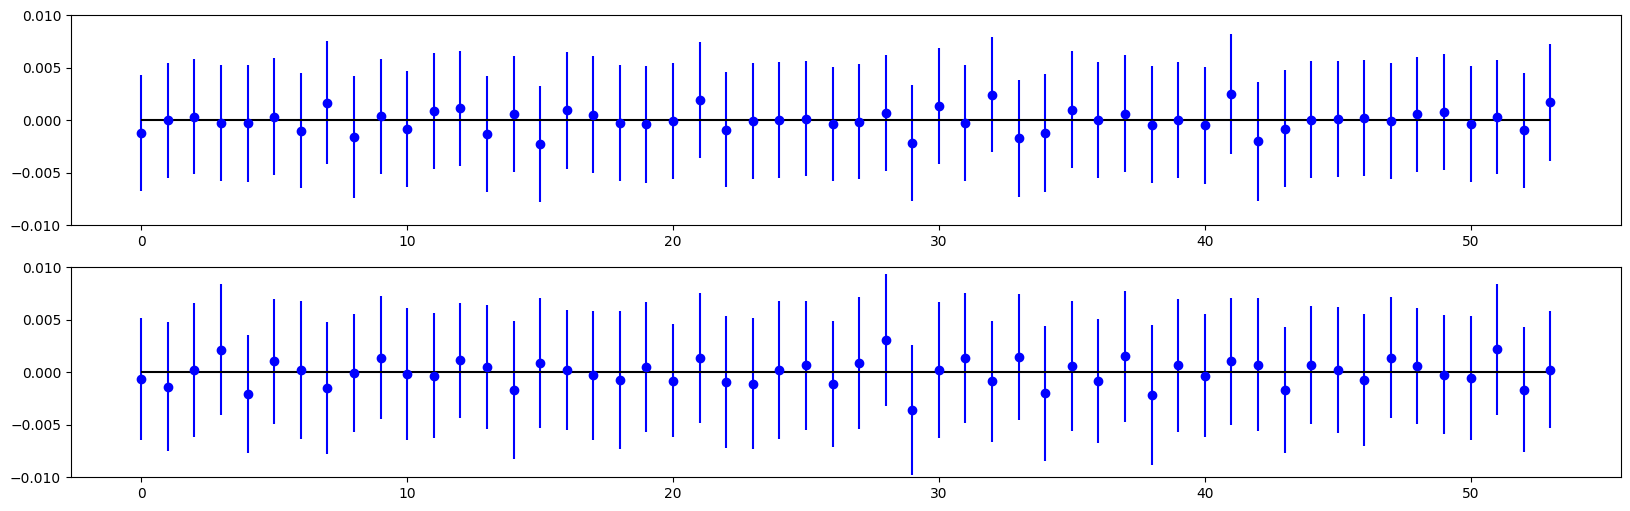

In [12]:
# Compare phase advance between adjacent monitor locations with correct data

plt.figure(figsize=(20, 3*2))

ax1 = plt.subplot(211)
ax1.errorbar(range(model.monitor_count), (fx_m - table.phase_x.cpu().numpy()), yerr=table.sigma_x.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax1.hlines(0, 0, model.monitor_count - 1, colors='black')
ax1.set_ylim(-1.0E-2, +1.0E-2)

ax2 = plt.subplot(212)
ax2.errorbar(range(model.monitor_count), (fy_m - table.phase_y.cpu().numpy()), yerr=table.sigma_y.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax2.hlines(0, 0, model.monitor_count - 1, colors='black')
ax2.set_ylim(-1.0E-2, +1.0E-2)

plt.show()

In [13]:
# Compute twiss from phase data using different range limit (upto 32)

box = []

for limit in range(1, 32 + 1):

    twiss = Twiss(model, table, limit=limit)

    twiss.phase_virtual()
    twiss.get_twiss_from_phase()
    mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': True, 'threshold': 0.5}, value={'use': True, 'threshold': 0.5}, sigma={'use': True, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
    mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': True, 'threshold': 0.5}, value={'use': True, 'threshold': 0.5}, sigma={'use': True, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})

    if twiss.limit != (1, 1):

        twiss.process_twiss(plane='x', mask=mask_x, weight=True)
        twiss.process_twiss(plane='y', mask=mask_y, weight=True)

    else:

        twiss.ax = twiss.data_phase['ax'].flatten()
        twiss.bx = twiss.data_phase['bx'].flatten()
        twiss.ay = twiss.data_phase['ay'].flatten()
        twiss.by = twiss.data_phase['by'].flatten()

        twiss.sigma_ax = twiss.data_phase['sigma_ax'].flatten()
        twiss.sigma_bx = twiss.data_phase['sigma_bx'].flatten()
        twiss.sigma_ay = twiss.data_phase['sigma_ay'].flatten()
        twiss.sigma_by = twiss.data_phase['sigma_by'].flatten()

    bx = twiss.bx[model.monitor_index].cpu().numpy()
    ax = twiss.ax[model.monitor_index].cpu().numpy()
    by = twiss.by[model.monitor_index].cpu().numpy()
    ay = twiss.ay[model.monitor_index].cpu().numpy()

    sigma_bx = twiss.sigma_bx[model.monitor_index].cpu().numpy()
    sigma_ax = twiss.sigma_ax[model.monitor_index].cpu().numpy()
    sigma_by = twiss.sigma_by[model.monitor_index].cpu().numpy()
    sigma_ay = twiss.sigma_ay[model.monitor_index].cpu().numpy()

    box.append(numpy.array([[bx, sigma_bx], [ax, sigma_ax], [by, sigma_by], [ay, sigma_ay]]))
    
    if limit <= 8:
        print(f'limit= {limit}: {"model":>12} {"error":>12}')
        print(f'error_bx: {numpy.abs(model.bx[model.monitor_index].cpu() - bx).sum().item():12.9} {numpy.abs(bx_m - bx).sum().item():12.9}')
        print(f'error_by: {numpy.abs(model.by[model.monitor_index].cpu() - by).sum().item():12.9} {numpy.abs(by_m - by).sum().item():12.9}')
        print(f'error_ax: {numpy.abs(model.ax[model.monitor_index].cpu() - ax).sum().item():12.9} {numpy.abs(ax_m - ax).sum().item():12.9}')
        print(f'error_ay: {numpy.abs(model.ay[model.monitor_index].cpu() - ay).sum().item():12.9} {numpy.abs(ay_m - ay).sum().item():12.9}')
        print()

box = numpy.array(box).T

# As it can be seen, for larger range limit value, bias increases
# Since the effect of noise in this example can be neglected, the discrepancy is only due to the bias
# Still, using limit=1 doesn't provide optimal accuracy
# In this example limit=2 is optimal, for larger values bias is stronger

limit= 1:        model        error
error_bx:   47.1839304    6.6846046
error_by:   50.7911439   13.8823706
error_ax:   11.1992295   1.32529187
error_ay:   10.4758682   2.21867605

limit= 2:        model        error
error_bx:   46.9795363   6.90417271
error_by:   60.1509958   14.7485813
error_ax:   11.1668145   1.36048061
error_ay:   13.1419311   3.27371929

limit= 3:        model        error
error_bx:   45.5134801   8.09343785
error_by:   58.5722297   13.0446809
error_ax:    10.626078   1.85810247
error_ay:   12.5927393   2.69512208

limit= 4:        model        error
error_bx:   47.9332582   6.77432704
error_by:   58.6823272   14.1667097
error_ax:   11.7490213   1.25322724
error_ay:   12.5567193   2.74307045

limit= 5:        model        error
error_bx:   49.5017951   6.06598865
error_by:   56.8621178   11.6845258
error_ax:   11.8924617    1.0317545
error_ay:   12.0779465   2.16635128

limit= 6:        model        error
error_bx:   50.0307259   5.49816959
error_by:   56.8018727 

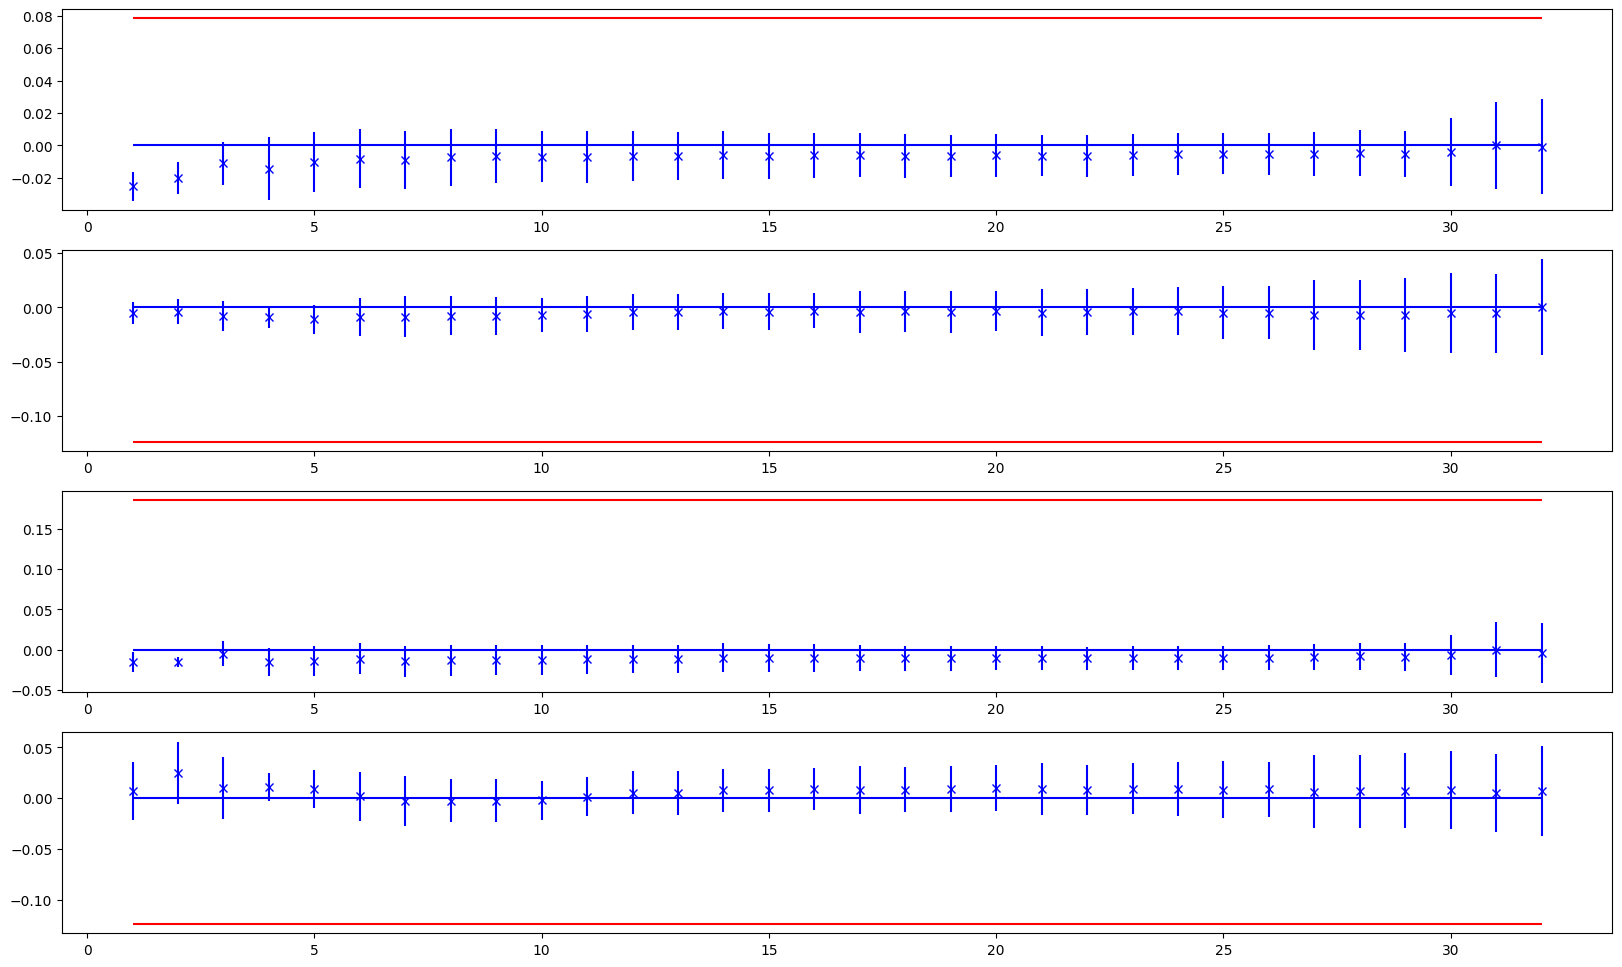

In [14]:
# Examine data for selected location

index = 0
out, sigma_out = box[index]

bx, ax, by, ay = out
sigma_bx, sigma_ax, sigma_by, sigma_ay = sigma_out

plt.figure(figsize=(20, 4*3))

ax1 = plt.subplot(411)
ax1.errorbar(range(1, 1 + len(bx)), (bx_m[index] - bx)/bx_m[index], yerr=sigma_bx/bx_m[index], fmt=' ', marker='x', color='blue')
ax1.hlines(0, 1, len(bx), colors='blue')
ax1.hlines((bx_m[index] - model.bx[model.monitor_index][index].cpu())/bx_m[index], 1, len(bx), colors='red')

ax2 = plt.subplot(412)
ax2.errorbar(range(1, 1 + len(by)), (by_m[index] - by)/by_m[index], yerr=sigma_by/by_m[index], fmt=' ', marker='x', color='blue')
ax2.hlines(0, 1, len(by), colors='blue')
ax2.hlines((by_m[index] - model.by[model.monitor_index][index].cpu())/by_m[index], 1, len(by), colors='red')

ax3 = plt.subplot(413)
ax3.errorbar(range(1, 1 + len(ax)), (ax_m[index] - ax)/ax_m[index], yerr=sigma_ax/abs(ax_m[index]), fmt=' ', marker='x', color='blue')
ax3.hlines(0, 1, len(ax), colors='blue')
ax3.hlines((ax_m[index] - model.ax[model.monitor_index][index].cpu())/ax_m[index], 1, len(bx), colors='red')

ax4 = plt.subplot(414)
ax4.errorbar(range(1, 1 + len(ay)), (ay_m[index] - ay)/ay_m[index], yerr=sigma_ay/abs(ay_m[index]), fmt=' ', marker='x', color='blue')
ax4.hlines(0, 1, len(ay), colors='blue')
ax4.hlines((ay_m[index] - model.ay[model.monitor_index][index].cpu())/ay_m[index], 1, len(bx), colors='red')

plt.show()

# Note, this bias will decrease for corrected lattice

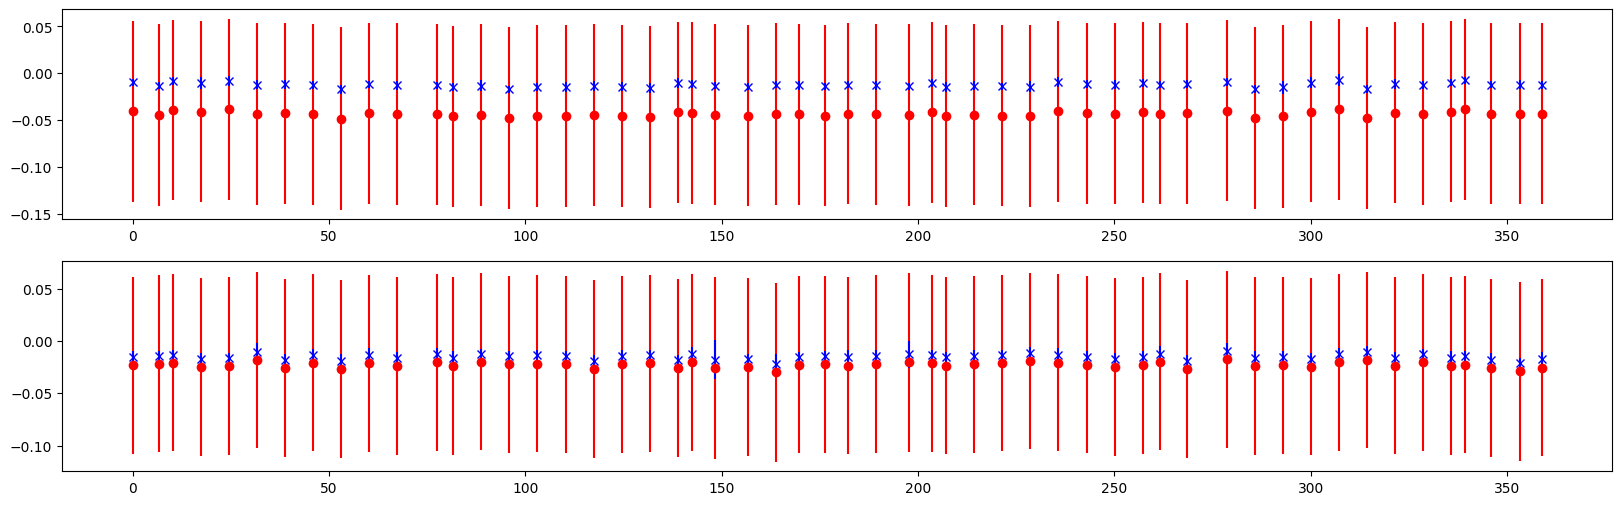

In [15]:
# Compute twiss from amplitude using twiss from phase data for action estimation

# Set twiss instance

twiss = Twiss(model, table, limit=4)


# Compute twiss from phase data
twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
twiss.process_twiss(plane='x', mask=mask_x, weight=True)
twiss.process_twiss(plane='y', mask=mask_y, weight=True)


# Twiss from amplitude using model for action estimation

twiss.get_action()
twiss.get_twiss_from_amplitude()
bx_1 = twiss.data_amplitude['bx'].cpu().numpy()
by_1 = twiss.data_amplitude['by'].cpu().numpy()
sigma_bx_1 = twiss.data_amplitude['sigma_bx'].cpu().numpy()
sigma_by_1 = twiss.data_amplitude['sigma_by'].cpu().numpy()

# Twiss from amplitude using twiss from phase for action estimation

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()
bx_2 = twiss.data_amplitude['bx'].cpu().numpy()
by_2 = twiss.data_amplitude['by'].cpu().numpy()
sigma_bx_2 = twiss.data_amplitude['sigma_bx'].cpu().numpy()
sigma_by_2 = twiss.data_amplitude['sigma_by'].cpu().numpy()

# Compare

plt.figure(figsize=(20, 3*2))

ax1 = plt.subplot(211)
ax1.errorbar(twiss.model.time[twiss.model.monitor_index].cpu().numpy(), (bx_m - bx_1)/bx_m, yerr=sigma_bx_1/bx_m, fmt=' ', marker='o', color='red')
ax1.errorbar(twiss.model.time[twiss.model.monitor_index].cpu().numpy(), (bx_m - bx_2)/bx_m, yerr=sigma_bx_2/bx_m, fmt=' ', marker='x', color='blue')

ax2 = plt.subplot(212)
ax2.errorbar(twiss.model.time[twiss.model.monitor_index].cpu().numpy(), (by_m - by_1)/by_m, yerr=sigma_by_1/by_m, fmt=' ', marker='o', color='red')
ax2.errorbar(twiss.model.time[twiss.model.monitor_index].cpu().numpy(), (by_m - by_2)/by_m, yerr=sigma_by_2/by_m, fmt=' ', marker='x', color='blue')

plt.show()

# Note, bias from action estimation (all values are shifted) is corrected

In [16]:
# Action spead (coupling)

print(twiss.action['spread_jx']/twiss.action['center_jx'])
print(twiss.action['spread_jy']/twiss.action['center_jy'])

tensor(3.539524451235e-03, dtype=torch.float64)
tensor(4.585631607312e-03, dtype=torch.float64)


tensor(6.891527541467e-02, dtype=torch.float64)
tensor(2.137221541941e-01, dtype=torch.float64)


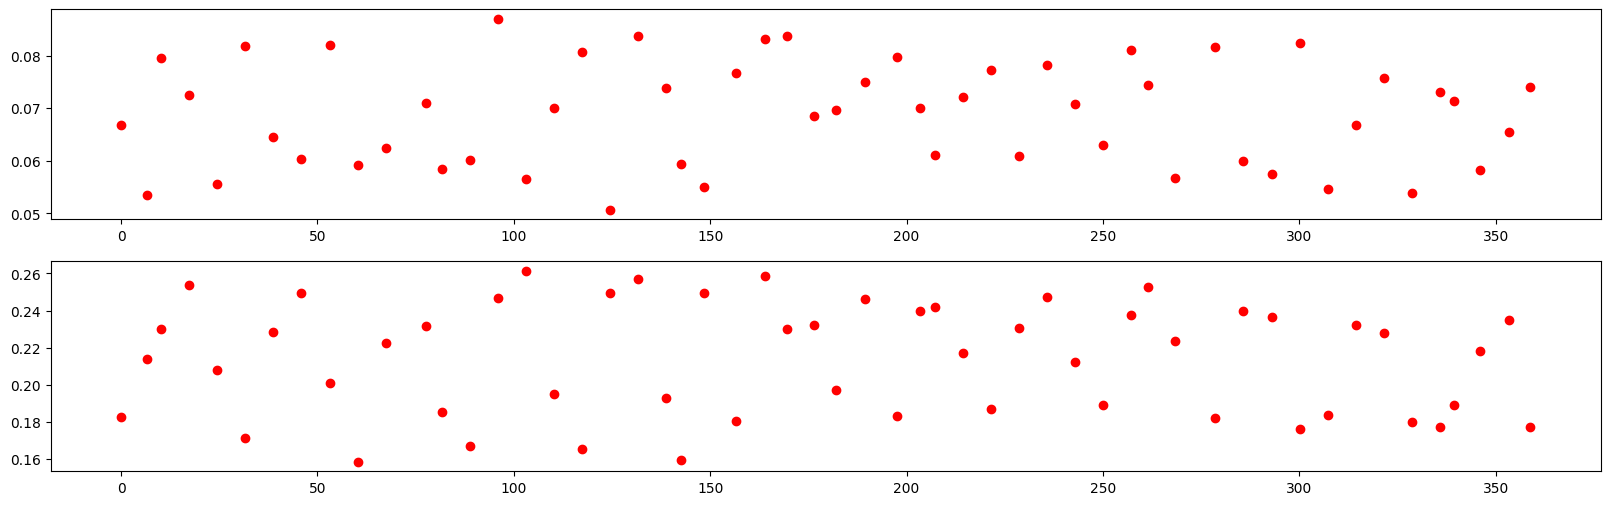

In [17]:
# Ratio (coupling)
# Can compute sigma

rx = axy/table.ax
ry = ayx/table.ay

print(rx.mean())
print(ry.mean())

plt.figure(figsize=(20, 3*2))
ax1 = plt.subplot(211)
ax1.scatter(twiss.model.time[twiss.model.monitor_index].cpu().numpy(), rx, marker='o', color='red')
ax2 = plt.subplot(212)
ax2.scatter(twiss.model.time[twiss.model.monitor_index].cpu().numpy(), ry, marker='o', color='red')
plt.show()